# **2026 Median Rent Analysis**

Malaysia Hodge | PHY/MAT 231 | Spring 2026

# **Project Background**


My dataset came from the Office of Policy Development and research (PD&R). They collect data for Fair Market Rent areas and through that have also collect the median rent for these areas. These datasets not only include the median rent for a studio-4 bedroom , but also the most recent population calculation, the state, and the county. As someone entering the adult world I know how important it is to find somewhere affordable to live. This database is actually used to help calulate living wage on the MIT living wage calculator website (https://livingwage.mit.edu/pages/methodology). With how extensive the data is there was not a lot of cleaning needed and gave way to a lot of questions I could answer.



# **Research Questions**

Q1 - How does the median rent in states differ? What states are most affordable? What statesare most expensive? (boxplots)

Q2 - How does median rent differ depending on the population of an area?

Q3 - How much has the median rent changed in the last year? Since 2019?

# **Setup**

## Importing Libraries

In [36]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import tabulate as t #makes it to where i can show tables in the print function
import numpy as np
import textwrap #so that my tick labels can wrap since some names are long
import seaborn as sns


## Loading the Data

In [37]:
# Load CSV
county_median26 = pd.read_csv('fy2026_fmr_50.csv') #data by county; median rent for 0-4 bedrooms (2026) This will be my main dataset and the rest are for comparison purposes
area_median26 = pd.read_csv('area_fy2026_fmr_50.csv') #data by area; median rent for 0-4 bedrooms (2026)
county_median25 = pd.read_csv('fy2025_fmr_50.csv') #data by county; median rent for 0-4 bedrooms (2025)
county_median19 = pd.read_csv('2019_county.csv') #data by county; median rent 0-4 bedrooms (2019)
# Load into SQLite
conn = sqlite3.connect(':memory:')

county_median26.to_sql('county26', conn, index=False)
area_median26.to_sql('area26', conn, index=False)
county_median25.to_sql('county25', conn, index=False)
county_median19.to_sql('county19', conn, index=False)

print(f"Median County Rent for 2026: {len(county_median26)} rows, columns: {list(county_median26.columns)}")
print(f"Median Area Rent for 2026: {len(area_median26)} rows, columns: {list(area_median26.columns)}")
print(f"Median County Rent for 2025: {len(county_median25)} rows, columns: {list(county_median25.columns)}")
print(f"Median County Rent for 2025: {len(county_median19)} rows, columns: {list(county_median19.columns)}")

county_median26.head()


Median County Rent for 2026: 4764 rows, columns: ['state_code', 'county_code', 'county_sub_code', 'cntyname', 'town_name', 'hud_areaname', 'fips2025', 'rent_50_0', 'rent_50_1', 'rent_50_2', 'rent_50_3', 'rent_50_4', 'hud_area_code', 'pop2023', 'state_alpha']
Median Area Rent for 2026: 2605 rows, columns: ['hud_area_code', 'hud_areaname', 'rent_50_0', 'rent_50_1', 'rent_50_2', 'rent_50_3', 'rent_50_4']
Median County Rent for 2025: 4764 rows, columns: ['state_code', 'county_code', 'county_sub_code', 'cntyname', 'town_name', 'hud_areaname', 'fips2010', 'rent_50_0', 'rent_50_1', 'rent_50_2', 'rent_50_3', 'rent_50_4', 'hud_area_code', 'pop2020', 'state_alpha']
Median County Rent for 2025: 4768 rows, columns: ['fips2010', 'rent50_0', 'rent50_1', 'rent50_2', 'rent50_3', 'rent50_4', 'state', 'cbsasub19', 'areaname19', 'county', 'cousub', 'cntyname', 'name', 'pop2010', 'hu2010', 'state_alpha']


,state_code,county_code,county_sub_code,cntyname,town_name,hud_areaname,fips2025,rent_50_0,rent_50_1,rent_50_2,rent_50_3,rent_50_4,hud_area_code,pop2023,state_alpha
0,1,15,99999,Calhoun County,NaN,"Anniston-Oxford, AL MSA",101599999,788,793,1007,1361,1425,METRO11500M11500,116162,AL
1,1,81,99999,Lee County,NaN,"Auburn-Opelika, AL HUD Metro FMR Area",108199999,929,1181,1295,1639,1863,METRO12220M12220,175126,AL
2,1,87,99999,Macon County,NaN,"Macon County, AL HUD Metro FMR Area",108799999,747,787,1033,1268,1558,METRO12220N01087,19198,AL
3,1,7,99999,Bibb County,NaN,"Birmingham-Hoover, AL HUD Metro FMR Area",100799999,1121,1265,1387,1735,1973,METRO13820M13820,22251,AL
4,1,9,99999,Blount County,NaN,"Birmingham-Hoover, AL HUD Metro FMR Area",100999999,1121,1265,1387,1735,1973,METRO13820M13820,59077,AL


## Describing the Data

In [38]:
# Summary statistics
county_median26.describe()


,state_code,county_code,county_sub_code,fips2025,rent_50_0,rent_50_1,rent_50_2,rent_50_3,rent_50_4,pop2023
count,4764.000000,4764.000000,4764.000000,4.764000e+03,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4.764000e+03
mean,30.374055,79.298489,80636.270571,3.045416e+09,1078.955290,1158.615659,1434.450672,1847.770571,2095.793451,7.026966e+04
std,15.052888,99.246842,30910.876582,1.506162e+09,417.902522,448.893811,542.331720,667.192420,751.223939,2.724923e+05
min,1.000000,1.000000,100.000000,1.002000e+08,424.000000,427.000000,487.000000,644.000000,655.000000,0.000000e+00
25%,21.000000,17.000000,63122.500000,2.107350e+09,756.000000,806.000000,1002.000000,1313.750000,1497.750000,3.969250e+03
50%,27.000000,45.000000,99999.000000,2.711300e+09,981.000000,1040.500000,1308.000000,1741.000000,1923.000000,1.492550e+04
75%,42.500000,113.000000,99999.000000,4.260076e+09,1310.000000,1389.000000,1720.750000,2259.500000,2647.000000,4.180750e+04
max,78.000000,999.000000,99999.000000,7.803100e+09,3310.000000,3434.000000,4388.000000,5599.000000,5892.000000,9.936690e+06


In [39]:
# Column types and missing values
county_median26.info()

<class 'pandas.DataFrame'>
RangeIndex: 4764 entries, 0 to 4763
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   state_code       4764 non-null   int64
 1   county_code      4764 non-null   int64
 2   county_sub_code  4764 non-null   int64
 3   cntyname         4764 non-null   str  
 4   town_name        1604 non-null   str  
 5   hud_areaname     4764 non-null   str  
 6   fips2025         4764 non-null   int64
 7   rent_50_0        4764 non-null   int64
 8   rent_50_1        4764 non-null   int64
 9   rent_50_2        4764 non-null   int64
 10  rent_50_3        4764 non-null   int64
 11  rent_50_4        4764 non-null   int64
 12  hud_area_code    4764 non-null   str  
 13  pop2023          4764 non-null   int64
 14  state_alpha      4764 non-null   str  
dtypes: int64(10), str(5)
memory usage: 558.4 KB


# **Question 1**

## How does the median rent in states differ? What states are most affordable? What states are most expensive?

## Analysis

In [40]:
# narrow it down and group by states (limit by 50 to take out the territories )
state_rent_26 =  pd.read_sql_query("""
                                   SELECT state_alpha, state_code, AVG(rent_50_0) AS studio, AVG(rent_50_1) AS one_bed, AVG(rent_50_2) AS two_bed, AVG(rent_50_3) AS three_bed, AVG(rent_50_4) AS four_bed
                                   FROM county26
                                   GROUP BY state_alpha 
                                   ORDER BY state_code ASC
                                   LIMIT 50  
                                   """, conn)

state_rent_26.to_sql('state26', conn, index=False) 



50

In [41]:
#gotta start another block because i cant run the "to_sql" function repeadetly
state_rent_26_max = pd.read_sql_query("""
                                      SELECT * FROM state26
                                      ORDER BY studio DESC
                                       LIMIT 5 
                                   """, conn)

state_rent_26_min = pd.read_sql_query("""
                                      SELECT * FROM state26
                                      ORDER BY studio ASC
                                       LIMIT 5 
                                   """, conn)

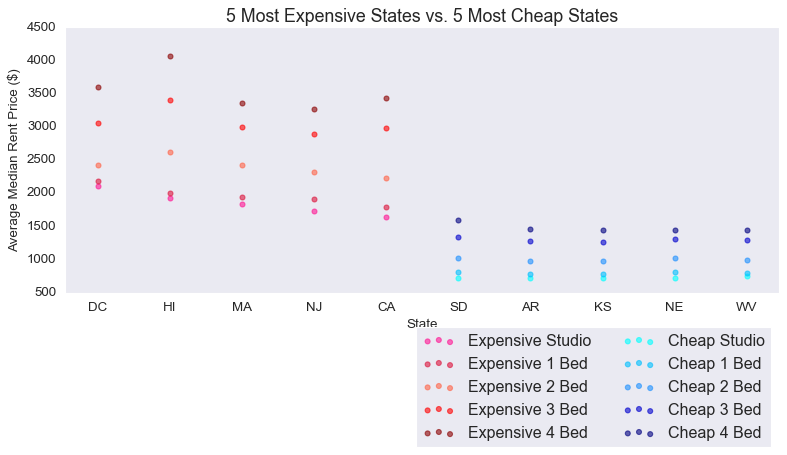

In [97]:
# Your visualization here

plt.figure(figsize=(10, 6))
plt.scatter(state_rent_26_max['state_alpha'], state_rent_26_max['studio'], alpha=0.6, color='deeppink', label='Expensive Studio')
plt.scatter(state_rent_26_max['state_alpha'], state_rent_26_max['one_bed'], alpha=0.6, color='crimson', label='Expensive 1 Bed')
plt.scatter(state_rent_26_max['state_alpha'], state_rent_26_max['two_bed'], alpha=0.6, color='tomato', label='Expensive 2 Bed')
plt.scatter(state_rent_26_max['state_alpha'], state_rent_26_max['three_bed'], alpha=0.6, color='red', label='Expensive 3 Bed')
plt.scatter(state_rent_26_max['state_alpha'], state_rent_26_max['four_bed'], alpha=0.6, color='darkred', label='Expensive 4 Bed')

plt.scatter(state_rent_26_min['state_alpha'], state_rent_26_min['studio'], alpha=0.6, color='cyan', label='Cheap Studio')
plt.scatter(state_rent_26_min['state_alpha'], state_rent_26_min['one_bed'], alpha=0.6, color='deepskyblue', label='Cheap 1 Bed')
plt.scatter(state_rent_26_min['state_alpha'], state_rent_26_min['two_bed'], alpha=0.6, color='dodgerblue', label='Cheap 2 Bed')
plt.scatter(state_rent_26_min['state_alpha'], state_rent_26_min['three_bed'], alpha=0.6, color='mediumblue', label='Cheap 3 Bed')
plt.scatter(state_rent_26_min['state_alpha'], state_rent_26_min['four_bed'], alpha=0.6, color='navy', label='Cheap 4 Bed')

plt.legend(loc='upper right', bbox_to_anchor=(1, -0.1), ncol=2)

sns.set_style("dark")

plt.title('5 Most Expensive States vs. 5 Most Cheap States', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Average Median Rent Price ($)', fontsize=12)
plt.tight_layout()
plt.show()

## Findings

There is a lot more variety in the more expensive states while for the cheap states there is not a lot of variety.

# **Question 2**

## Question

population of area vs rent

## Analysis

In [43]:
# Your analysis code here
area_pop_26 = pd.read_sql_query("""
                          SELECT hud_areaname, pop2023, state_alpha, state_code, AVG(rent_50_0) AS studio, AVG(rent_50_1) AS one_bed, AVG(rent_50_2) AS two_bed, AVG(rent_50_3) AS three_bed, AVG(rent_50_4) AS four_bed
                          FROM county26
                          GROUP BY hud_areaname      
                          ORDER BY state_code
                          """, conn)




In [44]:
area_pop_26.to_sql('pop26', conn, index=False) 

2605

In [45]:
area_pop_26_max = pd.read_sql_query("""
                                      SELECT * FROM pop26
                                      ORDER BY pop2023 DESC
                                       LIMIT 10 
                                   """, conn)

area_pop_26_min = pd.read_sql_query("""
                                      SELECT * FROM pop26
                                      ORDER BY pop2023 ASC
                                       LIMIT 10 
                                   """, conn)

area_pop_26_max


,hud_areaname,pop2023,state_alpha,state_code,studio,one_bed,two_bed,three_bed,four_bed
0,"Los Angeles-Long Beach-Glendale, CA HUD Metro ...",9936690,CA,6,2048.0,2292.0,2859.0,3625.0,4036.0
1,"Chicago-Joliet-Naperville, IL HUD Metro FMR Area",5225367,IL,17,1619.0,1730.0,1949.0,2510.0,2903.0
2,"Phoenix-Mesa-Chandler, AZ MSA",4430871,AZ,4,1588.0,1725.0,2004.0,2672.0,2964.0
3,"San Diego-Chula Vista-Carlsbad, CA MSA",3289701,CA,6,2482.0,2667.0,3255.0,4336.0,5255.0
4,"Santa Ana-Anaheim-Irvine, CA HUD Metro FMR Area",3175227,CA,6,2874.0,2943.0,3468.0,4708.0,5622.0
5,"Miami-Miami Beach-Kendall, FL HUD Metro FMR Area",2688237,FL,12,1970.0,2151.0,2626.0,3370.0,3895.0
6,"Riverside-San Bernardino-Ontario, CA MSA",2429487,CA,6,1866.0,1959.0,2427.0,3211.0,3875.0
7,"Las Vegas-Henderson-North Las Vegas, NV MSA",2265926,NV,32,1450.0,1608.0,1888.0,2626.0,3008.0
8,"Seattle-Bellevue, WA HUD Metro FMR Area",2254371,WA,53,2250.0,2328.0,2713.0,3550.0,4173.0
9,"Fort Lauderdale, FL HUD Metro FMR Area",1940907,FL,12,1869.0,2044.0,2510.0,3460.0,4099.0


In [46]:
#https://medium.com/dunder-data/automatically-wrap-graph-labels-in-matplotlib-and-seaborn-a48740bc9ce
#function to wrap my labels
def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels(minor=False):
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)

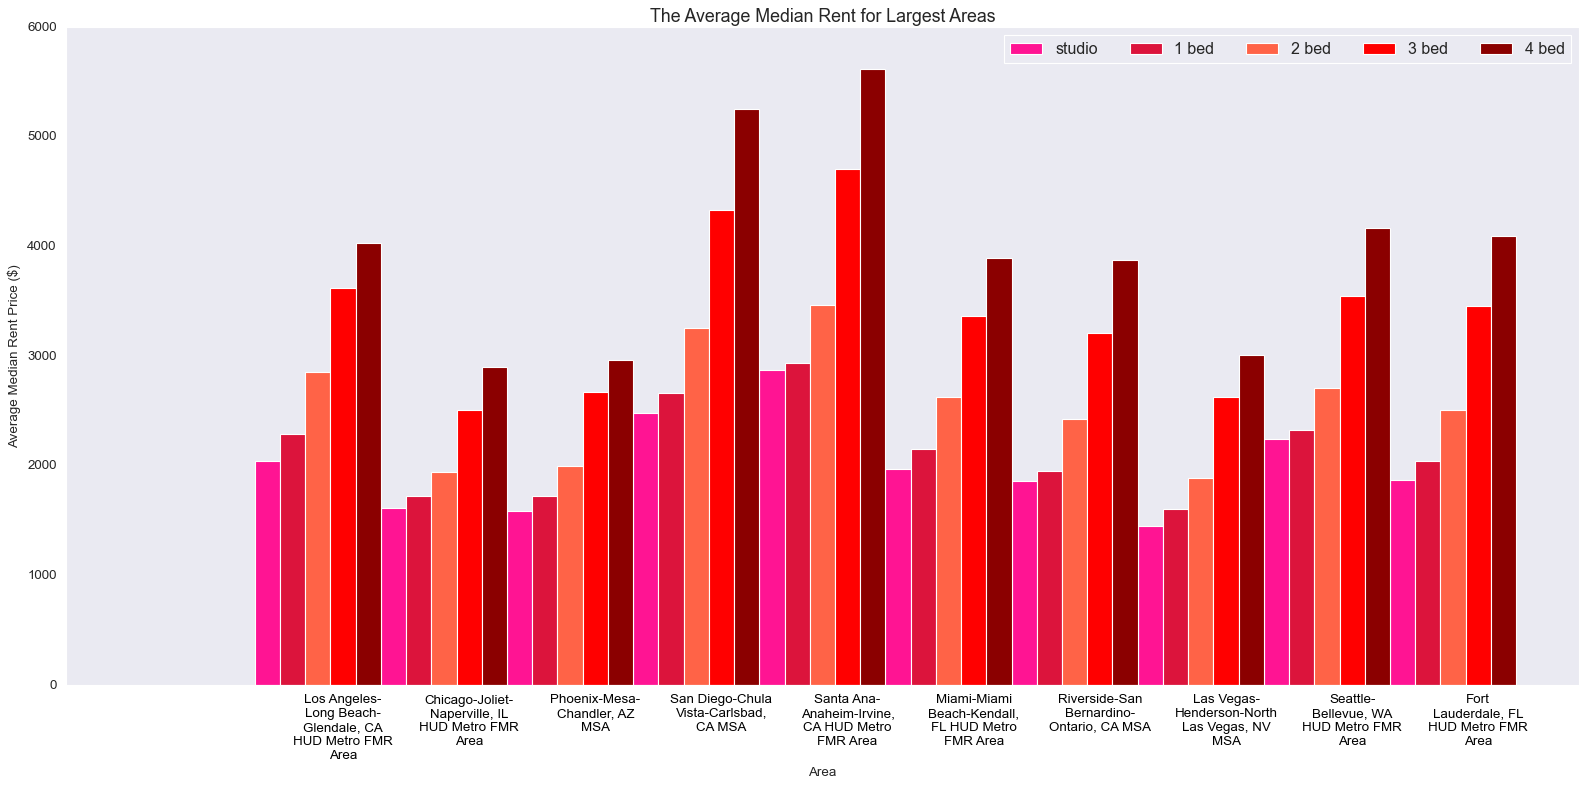

In [96]:

colors = ['deeppink', 'crimson', 'tomato', 'red', 'darkred',
          'cyan', 'deepskyblue', 'dodgerblue', 'mediumblue', 'navy']

fig, ax = plt.subplots(figsize=(20, 10))

index = np.arange(10)
bar_width = 0.2

r1 = ax.bar(index - (2*bar_width), area_pop_26_max['studio'],
       width = bar_width, color = colors[0], label = 'studio')

r2 = ax.bar(index - bar_width, area_pop_26_max['one_bed'],
       width = bar_width, color = colors[1], label = '1 bed')

r3 = ax.bar(index, area_pop_26_max['two_bed'],
       width = bar_width, color = colors[2], label = '2 bed')

r4 = ax.bar(index + bar_width, area_pop_26_max['three_bed'],
       width = bar_width, color = colors[3], label = '3 bed')

r5 = ax.bar(index + (2*bar_width), area_pop_26_max['four_bed'],
       width = bar_width, color = colors[4], label = '4 bed')


plt.xticks(index + bar_width, area_pop_26_max['hud_areaname'],
      color = 'black')

wrap_labels(ax, 15)

ax.legend(loc='upper right',  ncol=5)

sns.set_style("dark")

plt.title('The Average Median Rent for Largest Areas', fontsize=16)
plt.xlabel('Area', fontsize=12)
plt.ylabel('Average Median Rent Price ($)', fontsize=12)
plt.tight_layout()
plt.show()



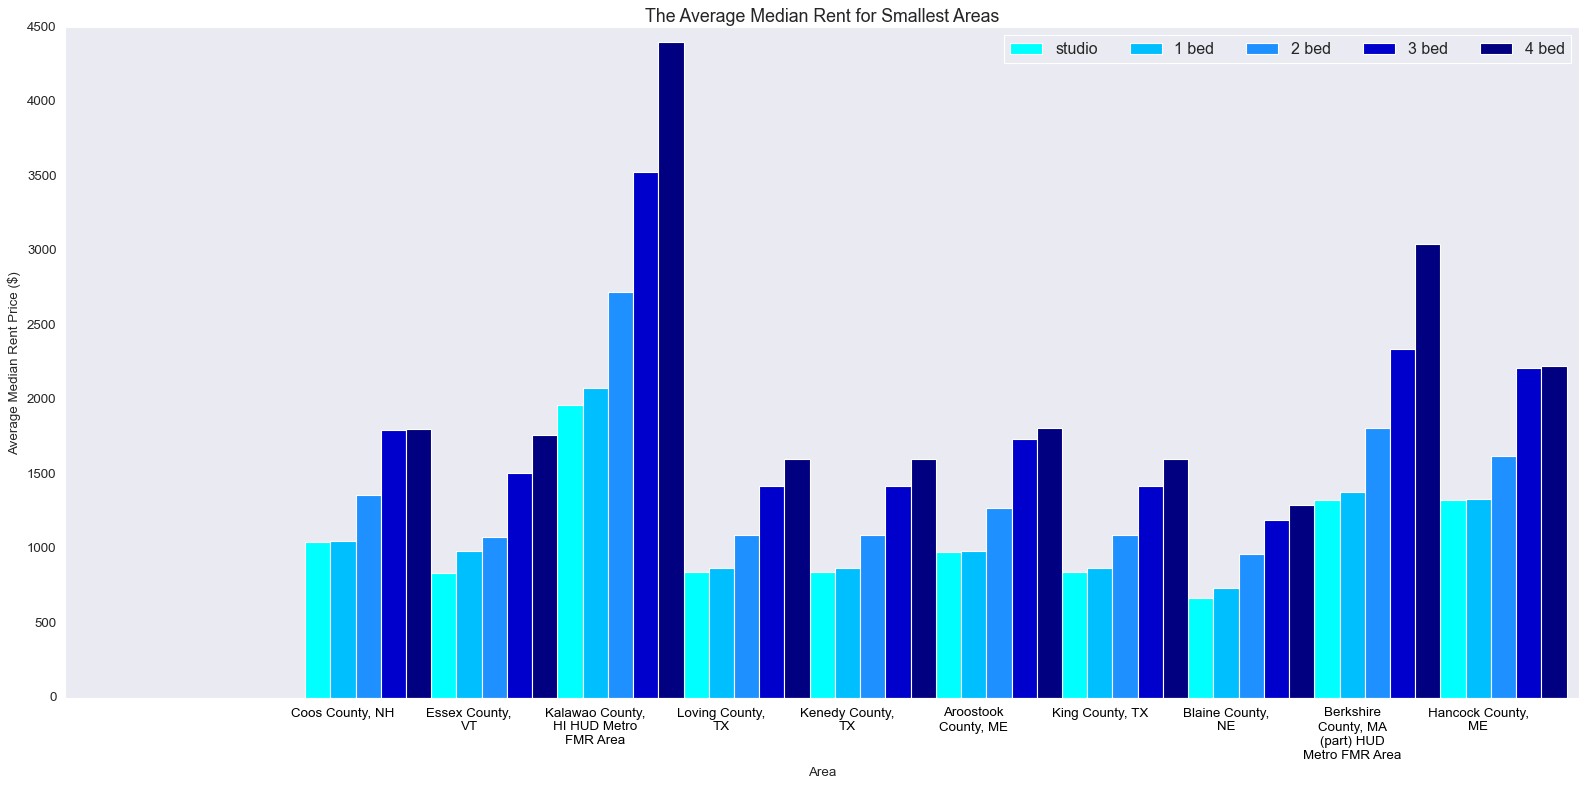

In [95]:
# Your visualization here

fig, ax = plt.subplots(figsize=(20, 10))

index = np.arange(10)
bar_width = 0.2

r1 = ax.bar(area_pop_26_min.index, area_pop_26_min['studio'],
       width = bar_width, color = colors[5], label = 'studio')

r2 = ax.bar(index + bar_width, area_pop_26_min['one_bed'],
       width = bar_width, color = colors[6], label = '1 bed')

r3 = ax.bar(index + (2*bar_width), area_pop_26_min['two_bed'],
       width = bar_width, color = colors[7], label = '2 bed')

r4 = ax.bar(index + (3*bar_width), area_pop_26_min['three_bed'],
       width = bar_width, color = colors[8], label = '3 bed')

r5 = ax.bar(index + (4*bar_width), area_pop_26_min['four_bed'],
       width = bar_width, color = colors[9], label = '4 bed')



plt.xticks(index + bar_width, area_pop_26_min['hud_areaname'],
      color = 'black', horizontalalignment = 'center')

wrap_labels(ax, 15)

ax.legend(loc='upper right',  ncol=5)

sns.set_style("dark")

plt.title('The Average Median Rent for Smallest Areas', fontsize=16)
plt.xlabel('Area', fontsize=12)
plt.ylabel('Average Median Rent Price ($)', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/ty/6lz99gvd7c5dfc0lc58dz2980000gn/T/ipykernel_26712/3924781201.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=0)


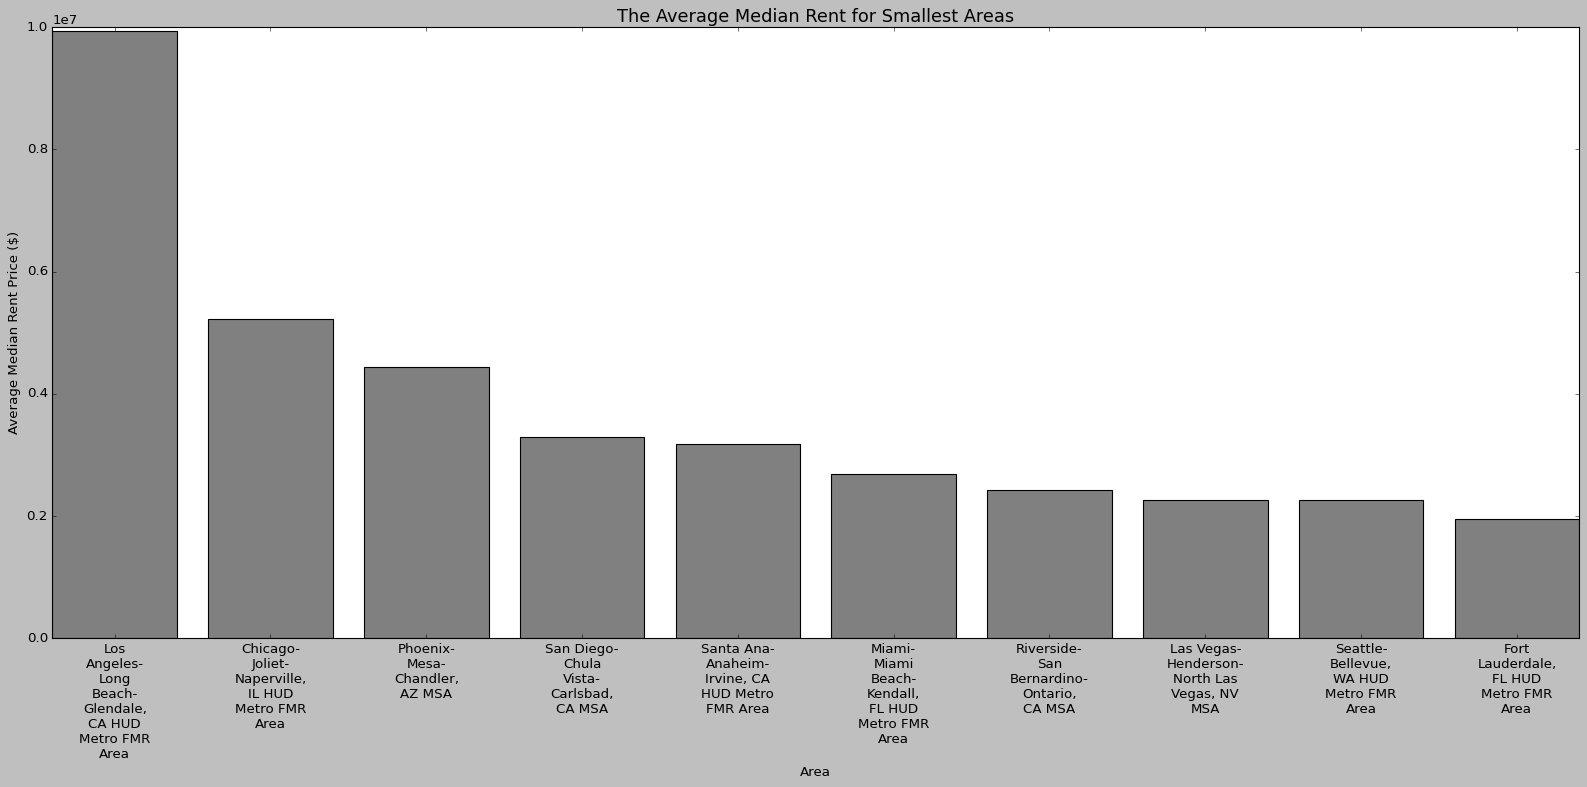

In [49]:
fig, ax = plt.subplots(figsize=(20, 10))

ax.bar(area_pop_26_max['hud_areaname'],area_pop_26_max['pop2023'], color='grey')

wrap_labels(ax, 10)

plt.style.use('classic')

plt.title('The Average Median Rent for Smallest Areas', fontsize=16)
plt.xlabel('Area', fontsize=12)
plt.ylabel('Average Median Rent Price ($)', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/ty/6lz99gvd7c5dfc0lc58dz2980000gn/T/ipykernel_26712/3924781201.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=0)


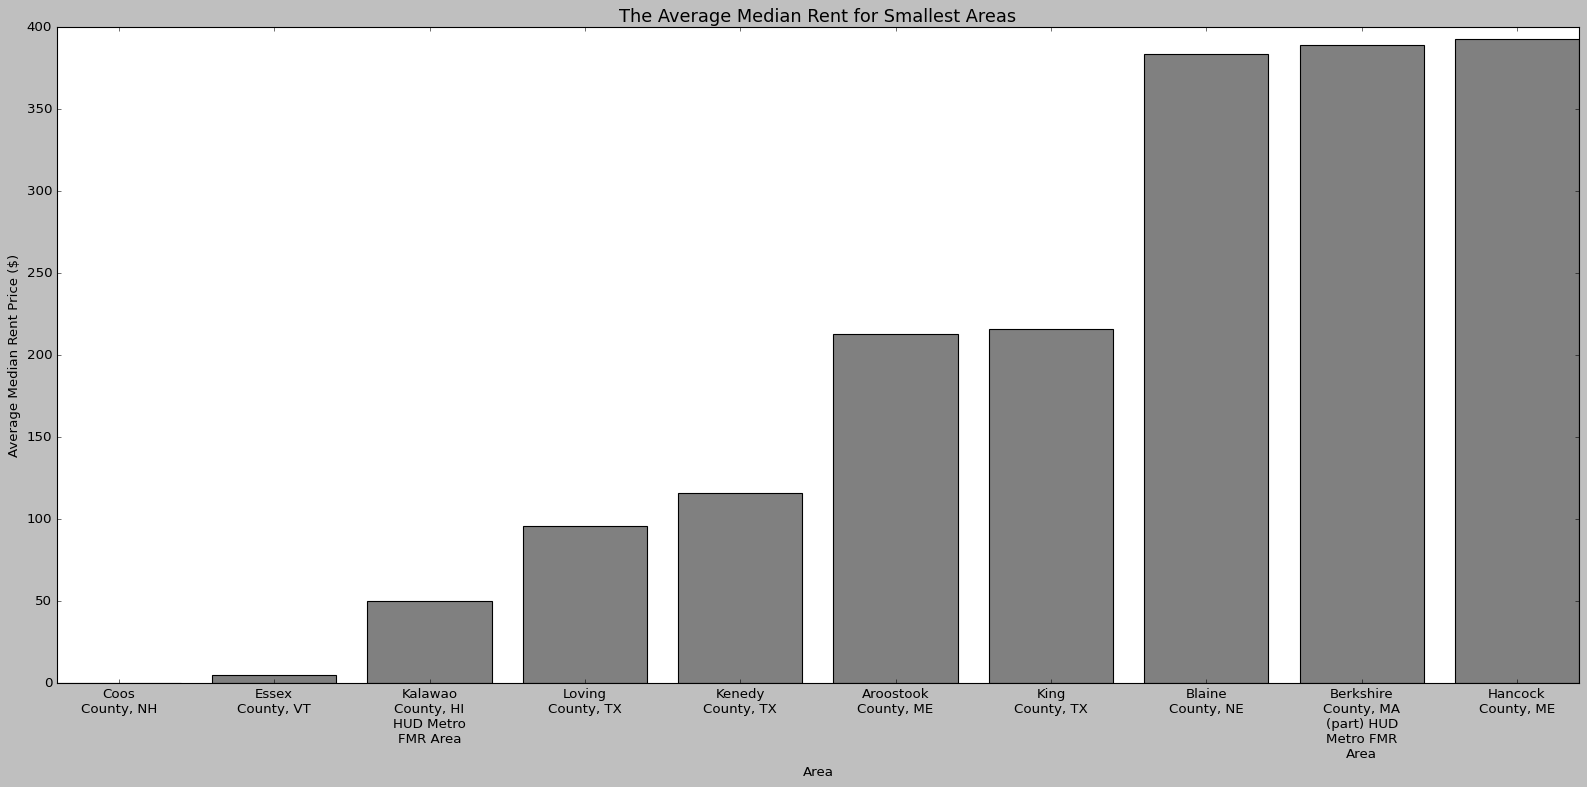

In [50]:
fig, ax = plt.subplots(figsize=(20, 10))

ax.bar(area_pop_26_min['hud_areaname'],area_pop_26_min['pop2023'], color='grey')

wrap_labels(ax, 10)

plt.style.use('classic')

plt.title('The Average Median Rent for Smallest Areas', fontsize=16)
plt.xlabel('Area', fontsize=12)
plt.ylabel('Average Median Rent Price ($)', fontsize=12)
plt.tight_layout()
plt.show()

## Findings

It is cheaper to live places with lower populations.

# **Question 3**

## Question

median 2026 vs 2025

## Analysis

In [51]:
# Your analysis code here
versus_26 = county_median26.groupby('state_alpha')[['rent_50_0','rent_50_1', 'rent_50_2', 'rent_50_3', 'rent_50_4']].mean()
versus_26['avg'] = versus_26[['rent_50_0','rent_50_1', 'rent_50_2', 'rent_50_3', 'rent_50_4']].mean(axis=1)
versus_25 = county_median25.groupby('state_alpha')[['rent_50_0','rent_50_1', 'rent_50_2', 'rent_50_3', 'rent_50_4']].mean()
versus_25['avg'] = versus_25[['rent_50_0','rent_50_1', 'rent_50_2', 'rent_50_3', 'rent_50_4']].mean(axis=1)
versus_19 = county_median19.groupby('state_alpha')[['rent50_0','rent50_1', 'rent50_2', 'rent50_3', 'rent50_4']].mean()
versus_19['avg'] = versus_19[['rent50_0','rent50_1', 'rent50_2', 'rent50_3', 'rent50_4']].mean(axis=1)

print(f"Median County Rent for 2026: {len(versus_26)} rows, columns: {list(versus_26.columns)}")
versus_25.head()


Median County Rent for 2026: 56 rows, columns: ['rent_50_0', 'rent_50_1', 'rent_50_2', 'rent_50_3', 'rent_50_4', 'avg']


,rent_50_0,rent_50_1,rent_50_2,rent_50_3,rent_50_4,avg
state_alpha,,,,,,
AK,1100.166667,1216.000000,1520.666667,2011.266667,2327.633333,1635.146667
AL,740.238806,802.253731,976.208955,1263.955224,1446.373134,1045.805970
AR,698.986667,743.226667,934.240000,1227.333333,1388.280000,998.413333
AS,825.000000,830.000000,1089.000000,1526.000000,1670.000000,1188.000000
AZ,1135.200000,1251.200000,1539.066667,2063.200000,2329.266667,1663.586667


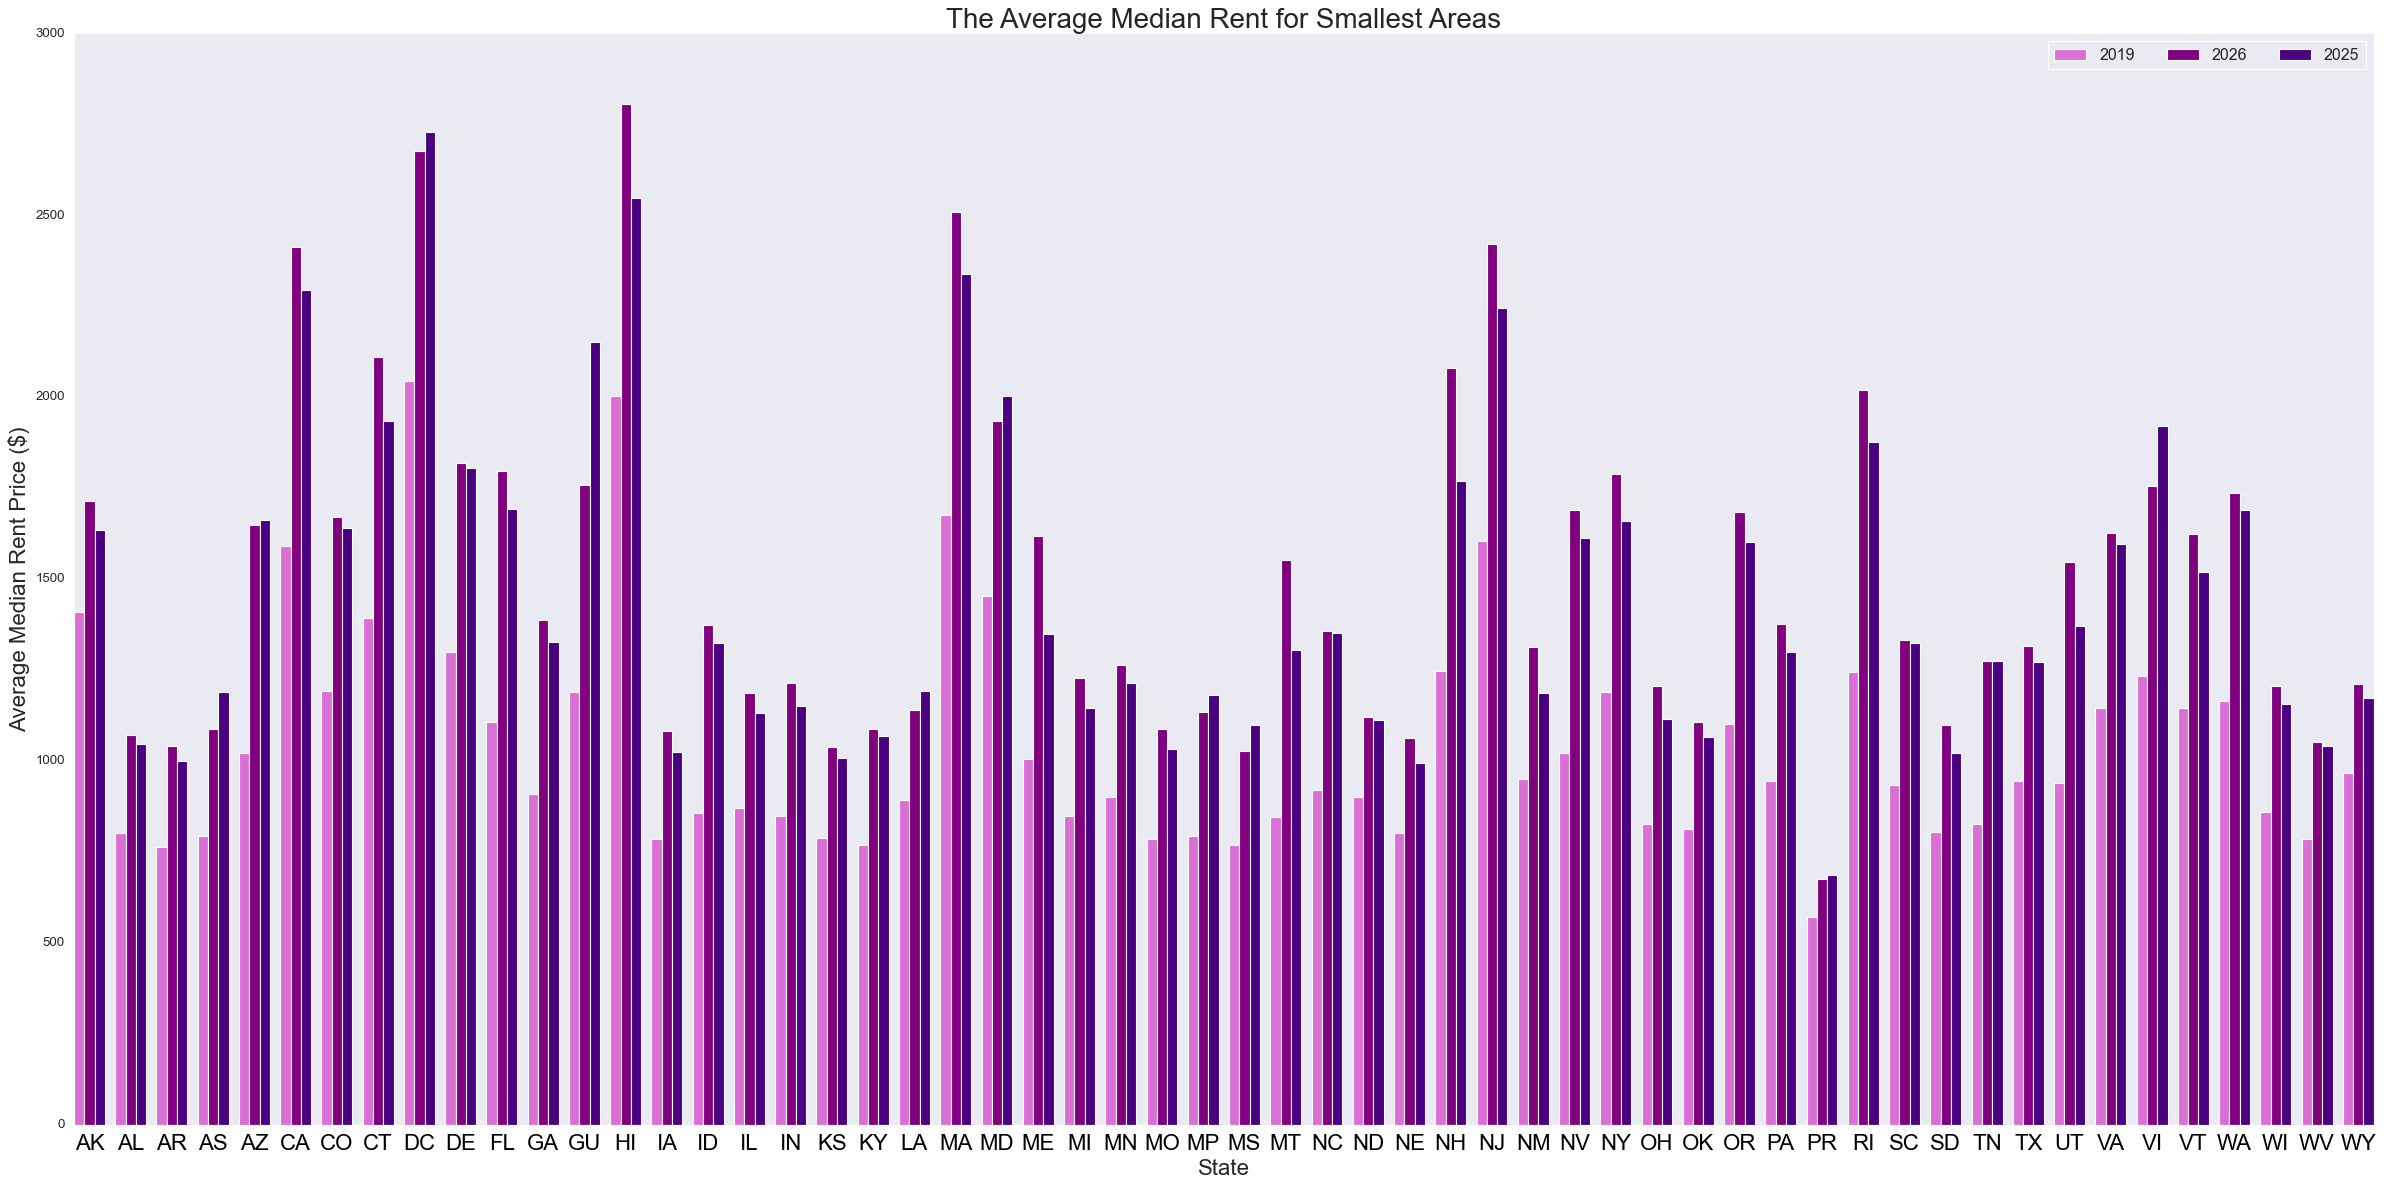

In [101]:
index = np.arange(56)
bar_width = 0.25

fig, ax = plt.subplots(figsize=(30, 15))

ax.bar(versus_19.index, versus_19['avg'], width=bar_width, color='orchid', label='2019')
ax.bar(index + bar_width, versus_26['avg'], width=bar_width, color='purple', label='2026')
ax.bar(index + (2*bar_width), versus_25['avg'], width=bar_width, color='indigo', label='2025')

ax.legend(loc='upper right',  ncol=5)

plt.xticks(index + bar_width, versus_25.index, color='black', fontsize=20)

plt.title('2019 vs 2025 vs 2026', fontsize=16)


sns.set_style("dark")

plt.title('The Average Median Rent for Smallest Areas', fontsize=25)
plt.xlabel('State', fontsize=20)
plt.ylabel('Average Median Rent Price ($)', fontsize=20)
plt.tight_layout()
plt.show()


## Findings

It actually looks like not only was rent cheaper in 2019 but is going back down slightly. Hopefully this means that while we dont see it now, that rent is going back down to 'normal' prices.

# **Conclusion**

## Summary of Findings

What did you learn? Go through each question and summarize what the data told you.

## Limitations

What couldn't your data answer? What would you do differently or explore next?

## Sources

- Dataset: (link)
- Any other sources you used

https://medium.com/@anshulrajput046/bar-charts-with-python-matplotlib-7eaac7ae76c9
https://matplotlib.org/cheatsheets/_images/cheatsheets-1.png
https://stackoverflow.com/questions/34734940/row-wise-average-for-a-subset-of-columns-with-missing-values

In [55]:
conn.close()